## CEIA - Análisis de datos — Ejercicio 2
### Moguilner Reh, Nicolás

#### EDA: ventas al por menor (Store Sales, Kaggle)

**Dataset:** [hassanjameelahmed/store-sales](https://www.kaggle.com/datasets/hassanjameelahmed/store-sales) descargado con `kagglehub`.

## 1. Imports y descarga del dataset
---

In [1]:
import os
from pathlib import Path

import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

import kagglehub

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Descarga la última versión del dataset en la caché de kagglehub
path = kagglehub.dataset_download("hassanjameelahmed/store-sales")
print("Ruta local del dataset:", path)

# En esta versión hay un único CSV
csv_files = list(Path(path).rglob("*.csv"))
for f in csv_files:
    print(f)

Ruta local del dataset: C:\Users\Nico\.cache\kagglehub\datasets\hassanjameelahmed\store-sales\versions\1
C:\Users\Nico\.cache\kagglehub\datasets\hassanjameelahmed\store-sales\versions\1\store_sales.csv


#### Descripción de las variables

Fuente: [hassanjameelahmed/store-sales](https://www.kaggle.com/datasets/hassanjameelahmed/store-sales)

| Variable | Tipo | Rango / Valores | Descripción |
|----------|------|-----------------|-------------|
| `CustomerID` | Integer | IDs únicos | Identificador único de cada cliente |
| `Age` | Integer | 20 — 70 años | Edad del cliente |
| `Gender` | String | Male, Female | Género del cliente |
| `Category` | String | 10 categorías | Categoría del producto (ej. Electronics, Clothing) |
| `ItemPurchased` | String | 30+ ítems | Artículo específico comprado |
| `Amount` | Float | $5.00 — $3,000.00 | Monto total de la transacción en USD |
| `Season` | String | Spring, Summer, Autumn, Winter | Estación en la que se realizó la compra |
| `PaymentMethod` | String | Card, Cash | Método de pago usado |
| `ItemRating` | Float | 1.0 — 5.0 | Puntuación de satisfacción del cliente con el producto |
| `DiscountApplied(%)` | Integer | 0% — 32% | Porcentaje de descuento aplicado a la transacción |
| `PreviousPurchases` | Integer | 0 — 13 | Cantidad de compras previas del cliente |



## 2. Funciones auxiliares
---

In [3]:
def plot_histograma(data, column, figsize=(6, 3), bins=20, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Desv. std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}', fontsize=10, color='orange')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

In [4]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [5]:
def print_categorias(dataframe, columna):
    print(f"Categorías en '{columna}': {dataframe[columna].nunique()}\n")
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    print(freq_tabla)

In [6]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal')

In [7]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, palette=palette, ax=ax, legend=False)
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)
    plt.show()

In [8]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col, palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col, palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')
    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

## 3. Carga y primera inspección
---

In [9]:
main_csv = csv_files[0]
df = pd.read_csv(main_csv)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (5000, 11)


,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB


In [11]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,NaN,NaN,NaN,45.2248,14.564995,20.0,33.0,45.0,58.0,70.0
Gender,5000,2,Female,2504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,5000,9,Footwear,983,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ItemPurchased,5000,30,Sandals,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount,5000.0,NaN,NaN,NaN,285.090522,551.454382,5.08,70.5475,122.485,184.535,2997.94
Season,5000,4,Spring,1300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,5000,2,Card,4009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ItemRating,5000.0,NaN,NaN,NaN,3.78416,0.681796,1.1,3.3,3.8,4.3,5.0
DiscountApplied(%),5000.0,NaN,NaN,NaN,14.9836,5.988063,0.0,11.0,15.0,19.0,36.0


#### Valores faltantes

In [12]:
df.isna().sum()

CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64

No se observan valores faltantes

#### Ajuste de tipos de variables

`CustomerID` es un identificador: no debe tratarse como cantidad en correlaciones; lo pasamos a `str` o `category`.

In [13]:
numericas = ['Age', 'Amount', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']
nominales = ['Gender', 'Category', 'ItemPurchased', 'Season', 'PaymentMethod']

dtype_map = {col: 'float64' for col in numericas}
dtype_map['CustomerID'] = 'string'
dtype_map.update({col: 'category' for col in nominales})

df = df.astype(dtype_map)
df.dtypes

CustomerID            string[python]
Age                          float64
Gender                      category
Category                    category
ItemPurchased               category
Amount                       float64
Season                      category
PaymentMethod               category
ItemRating                   float64
DiscountApplied(%)           float64
PreviousPurchases            float64
dtype: object

---
## 4. Estadística descriptiva — variables numéricas
---

#### 4.1.1 Tendencia central: media, mediana y moda (ejemplo: `Amount`)

In [14]:
col = 'Amount'
print('Media (numpy):', np.mean(df[col]))
print('Media (pandas):', df[col].mean())
print('Mediana:', df[col].median())
print('Moda:', df[col].mode()[0])

Media (numpy): 285.09052199999996
Media (pandas): 285.09052199999996
Mediana: 122.485
Moda: 108.5


#### 4.1.2 Tendencia central: media, mediana y moda (ejemplo: `Age`)

In [15]:
col = 'Age'
print('Media (numpy):', np.mean(df[col]))
print('Media (pandas):', df[col].mean())
print('Mediana:', df[col].median())
print('Moda:', df[col].mode()[0])

Media (numpy): 45.2248
Media (pandas): 45.2248
Mediana: 45.0
Moda: 42.0


#### 4.1.3 Tendencia central: media, mediana y moda (ejemplo: `ItemRating`)

In [16]:
col = 'ItemRating'
print('Media (numpy):', np.mean(df[col]))
print('Media (pandas):', df[col].mean())
print('Mediana:', df[col].median())
print('Moda:', df[col].mode()[0])

Media (numpy): 3.78416
Media (pandas): 3.78416
Mediana: 3.8
Moda: 3.8


#### 4.2 Histogramas y relación media–mediana–moda

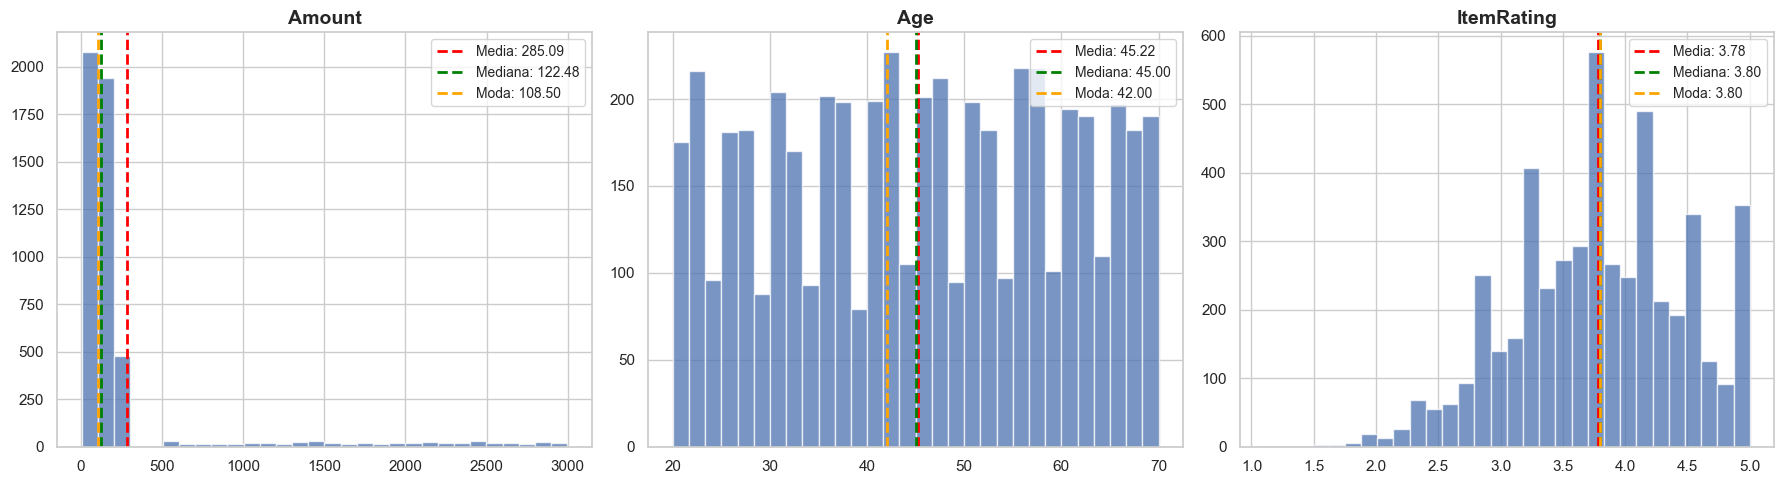

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, c in zip(axes, ['Amount', 'Age', 'ItemRating']):

    mean_val = df[c].mean()
    median_val = df[c].median()
    mode_val = df[c].mode()[0]

    ax.hist(df[c], bins=30, alpha=0.75)

    ax.axvline(mean_val, color='red', ls='--', linewidth=2,
               label=f'Media: {mean_val:.2f}')
    ax.axvline(median_val, color='green', ls='--', linewidth=2,
               label=f'Mediana: {median_val:.2f}')
    ax.axvline(mode_val, color='orange', ls='--', linewidth=2,
               label=f'Moda: {mode_val:.2f}')

    ax.set_title(c, fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

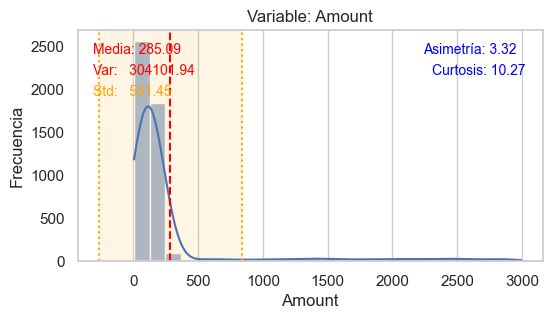

In [18]:
plot_histograma(df, 'Amount', bins=25, snk=True)

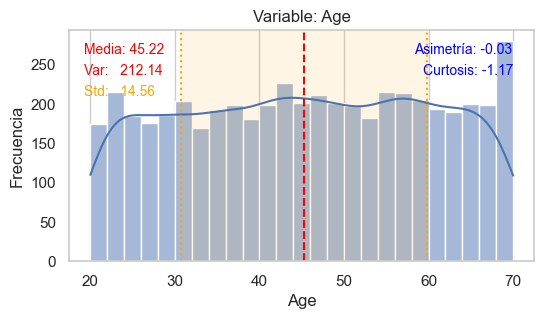

In [19]:
plot_histograma(df, 'Age', bins=25, snk=True)

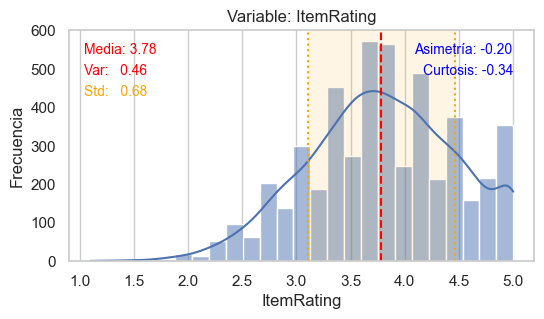

In [20]:
plot_histograma(df, 'ItemRating', bins=25, snk=True)

In [21]:
describe_df = df.describe().T

# agrego kurtosis y asimetria
describe_df['skew'] = df.skew(numeric_only=True)
describe_df['kurtosis'] = df.kurtosis(numeric_only=True)

describe_df

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Age,5000.0,45.224800,14.564995,20.00,33.0000,45.000,58.000,70.00,-0.030226,-1.173409
Amount,5000.0,285.090522,551.454382,5.08,70.5475,122.485,184.535,2997.94,3.323766,10.268284
ItemRating,5000.0,3.784160,0.681796,1.10,3.3000,3.800,4.300,5.00,-0.203256,-0.335265
DiscountApplied(%),5000.0,14.983600,5.988063,0.00,11.0000,15.000,19.000,36.00,0.197853,-0.273299
PreviousPurchases,5000.0,5.008800,2.194285,0.00,3.0000,5.000,6.000,13.00,0.391680,0.031672


Dada la marcada asimetría positiva en el monto de las compras, se investigan los casos de valores elevados (outliers) para identificar a qué tipo de productos o categorías están asociados.

In [22]:

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Amount'] < lower) |
    (df['Amount'] > upper)
]

outliers.head(20)


,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
6,7,54.0,Male,Electronics,Mobile Phone,1396.16,Autumn,Card,4.7,18.0,4.0
8,9,51.0,Male,Electronics,Smart Watch,2238.79,Spring,Card,4.3,20.0,5.0
30,31,43.0,Male,Electronics,Smart Watch,1572.49,Autumn,Card,3.5,14.0,7.0
41,42,22.0,Male,Electronics,Laptop,2392.70,Winter,Card,5.0,6.0,3.0
43,44,66.0,Male,Electronics,Mobile Phone,2260.20,Spring,Card,4.6,9.0,2.0
58,59,34.0,Male,Electronics,Headphones,1459.73,Spring,Card,4.0,24.0,7.0
66,67,25.0,Male,Electronics,Laptop,1951.47,Autumn,Card,3.8,14.0,2.0
77,78,38.0,Male,Electronics,Mobile Phone,2888.09,Winter,Card,3.6,8.0,4.0
87,88,44.0,Male,Electronics,Mobile Phone,1643.58,Autumn,Card,3.2,11.0,3.0
88,89,61.0,Male,Electronics,Laptop,2338.03,Spring,Card,3.8,14.0,2.0


In [23]:
outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,507.0,44.861933,14.446189,20.00,33.00,46.00,56.50,70.00
Amount,507.0,1766.079586,724.086311,500.44,1169.88,1775.37,2408.71,2997.94
ItemRating,507.0,3.786193,0.662585,1.90,3.40,3.80,4.30,5.00
DiscountApplied(%),507.0,14.984221,5.982496,0.00,11.00,15.00,19.00,32.00
PreviousPurchases,507.0,4.962525,2.220230,0.00,3.00,5.00,6.00,13.00


#### 4.3 Cuartiles y rango intercuartil

In [24]:
for col in ['Amount', 'Age', 'ItemRating']:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.50)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"\n{col}")
    print(f"Q1={Q1:.2f}, Q2(mediana)={Q2:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")


Amount
Q1=70.55, Q2(mediana)=122.48, Q3=184.53, IQR=113.99

Age
Q1=33.00, Q2(mediana)=45.00, Q3=58.00, IQR=25.00

ItemRating
Q1=3.30, Q2(mediana)=3.80, Q3=4.30, IQR=1.00


#### 4.4 Observaciones

#### `Amount`
Distribución fuertemente sesgada a la derecha (`skew = 3.32`, `kurtosis = 10.27`).  
La media (\$285) es considerablemente mayor que la mediana (\$122), lo que sugiere la presencia de valores altos extremos (*outliers*) que elevan el promedio.

#### `Age`
Distribución relativamente uniforme entre los 20 y 70 años (`mean = 45`, `median = 45`, `std = 14.6`).  
No se observa un grupo etario claramente predominante, indicando una base de clientes heterogénea.

#### `ItemRating`
Leve asimetría negativa (`skew = -0.20`).  
La mayoría de las calificaciones se concentra entre 3.3 y 4.3, con una mediana de 3.8, lo que sugiere un nivel general de satisfacción alto y pocos valores extremadamente bajos.

---
## 5. Variables categóricas
---

In [25]:
for c in nominales:
    print("=" * 50)
    print_categorias(df, c)
    print()

Categorías en 'Gender': 2

        Frecuencia absoluta  Frecuencia relativa (%)
Gender                                              
Female                 2504                    50.08
Male                   2496                    49.92

Categorías en 'Category': 9

                 Frecuencia absoluta  Frecuencia relativa (%)
Category                                                     
Footwear                         983                    19.66
Sports                           835                    16.70
Womens Clothing                  547                    10.94
Beauty                           529                    10.58
Mens Clothing                    511                    10.22
Electronics                      507                    10.14
Accessories                      470                     9.40
Groceries                        332                     6.64
Home                             286                     5.72

Categorías en 'ItemPurchased': 30

             

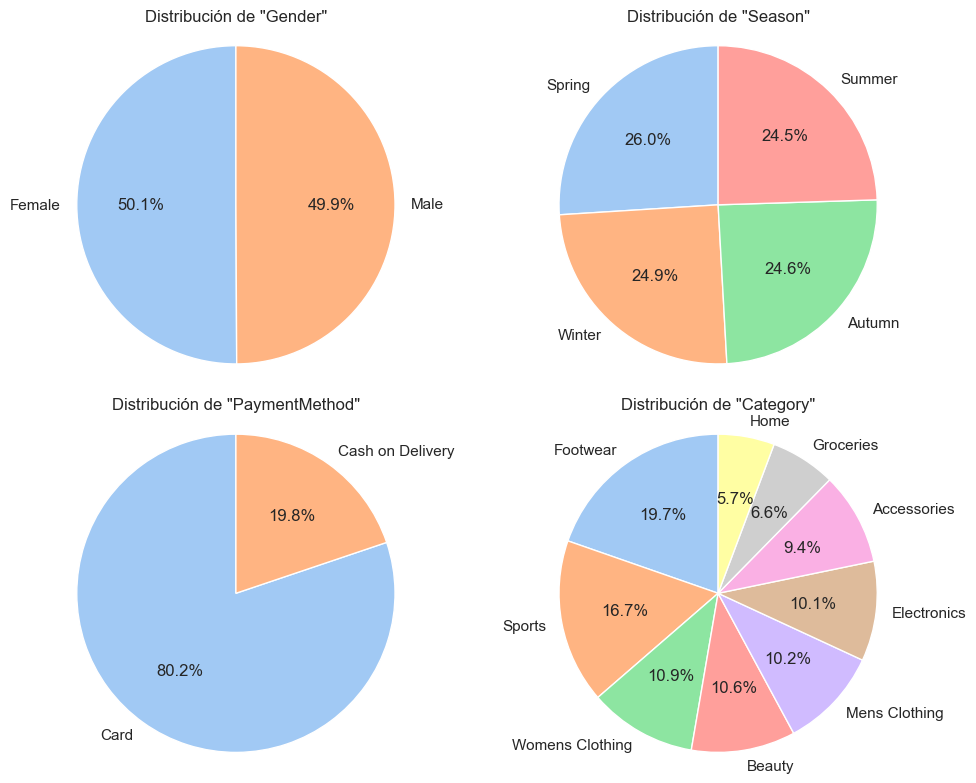

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, c in zip(axes.ravel(), ['Gender', 'Season', 'PaymentMethod', 'Category']):
    plot_pie(df, c, ax=ax)
plt.tight_layout()
plt.show()

#### Observaciones — Pie charts (`Gender`, `Season`, `PaymentMethod`, `Category`)

- **`Gender`:** distribución prácticamente equilibrada (Female 50.1% — Male 49.9%). Este balance tan preciso sugiere un posible muestreo controlado o dataset sintético.

- **`Season`:** las cuatro estaciones presentan proporciones muy similares (~25% cada una). Spring muestra una leve predominancia (26%), sin diferencias relevantes. La estacionalidad no parece influir significativamente en el volumen de transacciones.

- **`PaymentMethod`:** fuerte dominancia de tarjeta (80.2%, 4009 de 5000 transacciones), frente a efectivo (19.8%). Se observa una clara preferencia.

- **`Category`:** Footwear es la categoría más frecuente (~20%), seguida por Sports (16.7%). En el extremo opuesto, Groceries (6.6%) y Home (5.7%) presentan menor participación. Cabe destacar que la frecuencia de compra no implica necesariamente mayor facturación, ya que, como se observó en el apartado anterior, los tickets más altos corresponden a productos de Electronics, los cuales presentan una frecuencia de compra menor en comparación con otras categorías, como las vinculadas a indumentaria.

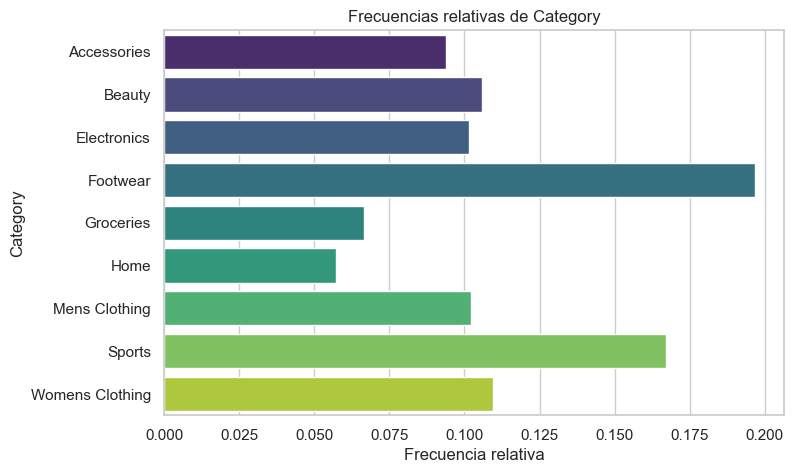

In [27]:
plot_frecuencias_relativas(df, 'Category', figsize=(8, 5))

#### Observaciones — frecuencias relativas de `Category`

- **Footwear + Sports (36.4%)**: en conjunto representan más de un tercio del total de transacciones, concentrando una parte importante del volumen de compras.

- **Electronics (10.1%)**: aunque su participación en cantidad de compras es baja, se destaca por su elevado ticket medio (~\$1766), lo que sugiere alta contribución a la facturación con baja frecuencia de compra.

- **Groceries + Home (12.4%)**: en conjunto representan una proporción menor del total, posicionándose como categorías de baja frecuencia y menor impacto en volumen de transacciones.


#### Comparación de una numérica respecto de una categórica (box + violin)

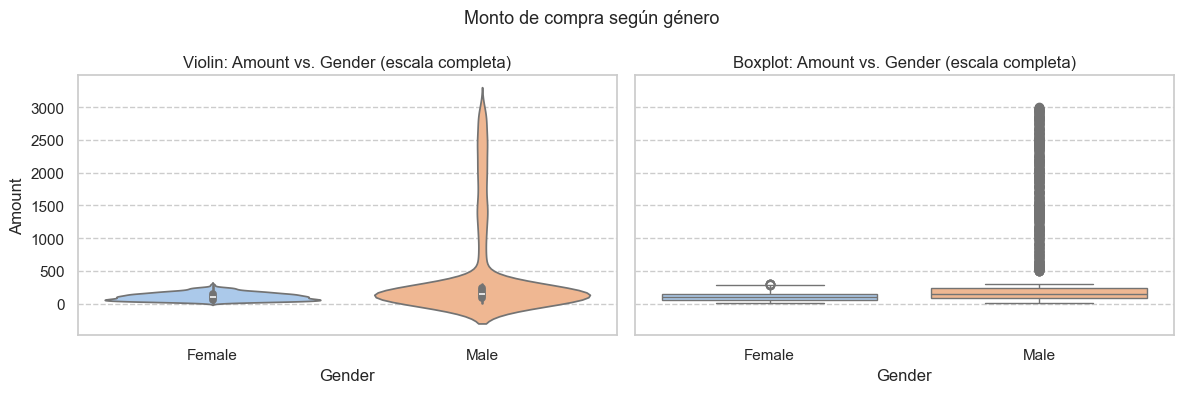

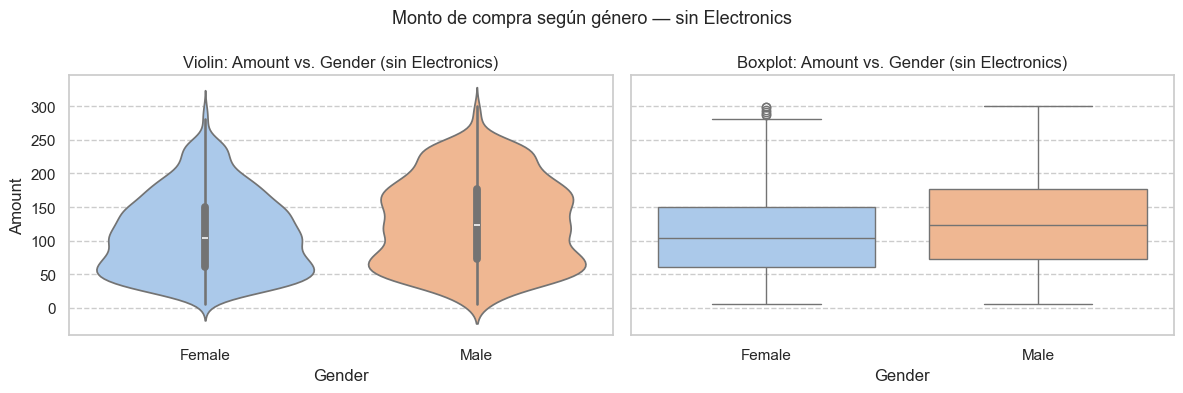

In [28]:
# ── Escala completa (para ver los outliers de Electronics) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.violinplot(data=df, x='Gender', y='Amount', hue='Gender',
               palette='pastel', ax=axes[0], legend=False)
axes[0].set_title('Violin: Amount vs. Gender (escala completa)')
axes[0].grid(axis='y', ls='--')
sns.boxplot(data=df, x='Gender', y='Amount', hue='Gender',
            palette='pastel', ax=axes[1], legend=False)
axes[1].set_title('Boxplot: Amount vs. Gender (escala completa)')
axes[1].grid(axis='y', ls='--')
plt.suptitle('Monto de compra según género', fontsize=13)
plt.tight_layout()
plt.show()

# ── Zoom excluyendo Electronics: el IQR se distingue bien ──────────────────
df_sin_elec = df[df['Category'] != 'Electronics']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.violinplot(data=df_sin_elec, x='Gender', y='Amount', hue='Gender',
               palette='pastel', ax=axes[0], legend=False)
axes[0].set_title('Violin: Amount vs. Gender (sin Electronics)')
axes[0].grid(axis='y', ls='--')
sns.boxplot(data=df_sin_elec, x='Gender', y='Amount', hue='Gender',
            palette='pastel', ax=axes[1], legend=False)
axes[1].set_title('Boxplot: Amount vs. Gender (sin Electronics)')
axes[1].grid(axis='y', ls='--')
plt.suptitle('Monto de compra según género — sin Electronics', fontsize=13)
plt.tight_layout()
plt.show()

#### Observaciones — `Amount` vs `Gender`

- En la escala completa, los violines y boxplots aparecen comprimidos debido a la fuerte influencia de valores extremos (hasta ~\$2998), principalmente asociados a la categoría de Electronics. Por este motivo, se utiliza una segunda versión sin dicha categoría para analizar mejor la distribución central (IQR).

- Sin Electronics, se observa una diferencia más clara entre géneros: la mediana de los hombres es de aproximadamente \$117, mientras que la de las mujeres es de ~\$104. Además, las distribuciones presentan formas ligeramente diferentes.

- En la versión completa se evidencian outliers más altos en hombres que no se observan en mujeres, lo que sugiere una mayor concentración de compras de alto valor en el segmento masculino.

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_26128\3937994039.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_gender = df.groupby(['Category', 'Gender']).size().unstack(fill_value=0)


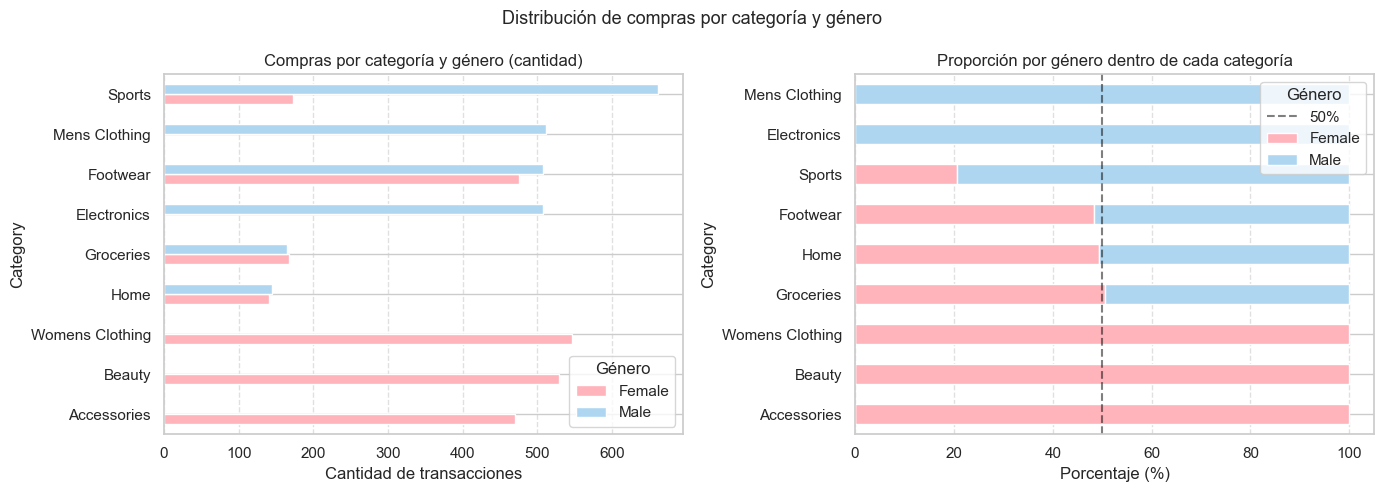

In [29]:
# ¿Qué categorías compra cada género?
cat_gender = df.groupby(['Category', 'Gender']).size().unstack(fill_value=0)
cat_gender_pct = cat_gender.div(cat_gender.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cantidad absoluta de compras
cat_gender.sort_values('Male').plot(kind='barh', ax=axes[0],
                                    color=['#FFB3BA', '#AED6F1'], edgecolor='white')
axes[0].set_title('Compras por categoría y género (cantidad)')
axes[0].set_xlabel('Cantidad de transacciones')
axes[0].legend(title='Género')
axes[0].grid(axis='x', ls='--', alpha=0.6)

# Proporción dentro de cada categoría (stacked 100%)
cat_gender_pct.sort_values('Male').plot(kind='barh', stacked=True, ax=axes[1],
                                         color=['#FFB3BA', '#AED6F1'], edgecolor='white')
axes[1].axvline(50, color='black', linestyle='--', alpha=0.5, label='50%')
axes[1].set_title('Proporción por género dentro de cada categoría')
axes[1].set_xlabel('Porcentaje (%)')
axes[1].legend(title='Género')
axes[1].grid(axis='x', ls='--', alpha=0.6)

plt.suptitle('Distribución de compras por categoría y género', fontsize=13)
plt.tight_layout()
plt.show()

#### Observaciones — compras por `Category` y `Gender`

- **Electronics** es la categoría con mayor desequilibrio entre géneros, con una clara predominancia de compras por parte de hombres. Esto contribuye de forma significativa a explicar la diferencia en el monto promedio de compras observada entre géneros.

- **Womens Clothing** y **Beauty** presentan una mayor participación de compradoras, mostrando un sesgo natural hacia el público femenino en estas categorías.

- El resto de las categorías (Footwear, Sports, Accessories, Groceries, entre otras) muestran una distribución relativamente equilibrada entre géneros, con proporciones cercanas al 50/50.

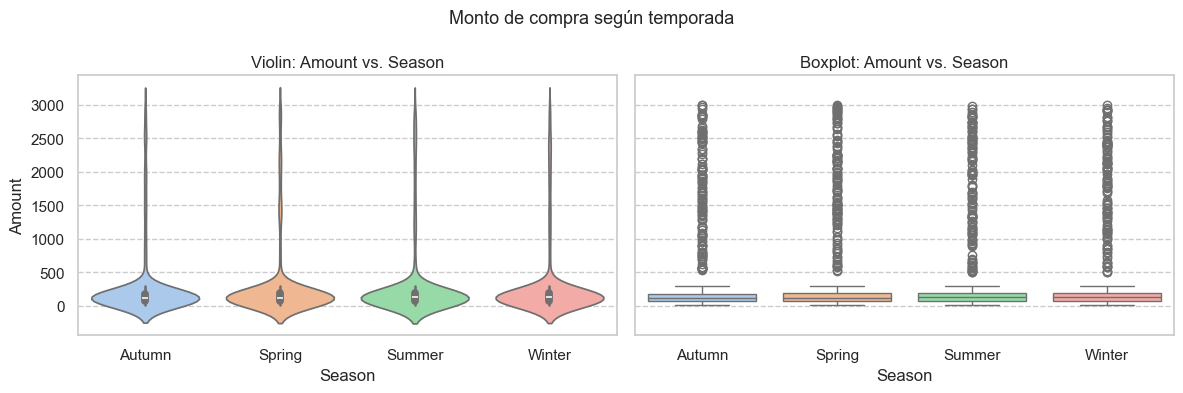

In [30]:
plot_violin_box(df, 'Amount', 'Season', title='Monto de compra según temporada')

#### Observaciones — `Amount` vs `Season`

- Las medianas son prácticamente idénticas en las cuatro estaciones: Autumn (\$120), Spring (\$122), Summer (\$124) y Winter (\$123). Esto indica que la estación del año no tiene un impacto significativo en el ticket mediano de compra.

- Las medias también son muy similares (aprox. \$280–\$289), y los valores máximos alcanzan niveles cercanos a \$2990 en todas las estaciones.

- Los valores extremos (outliers) se distribuyen de manera uniforme entre estaciones, lo que sugiere que no existe una estacionalidad marcada en las compras de alto valor dentro del dataset.

- En conclusión, la variable `Season` aporta poca capacidad explicativa para el monto gastado por transacción.

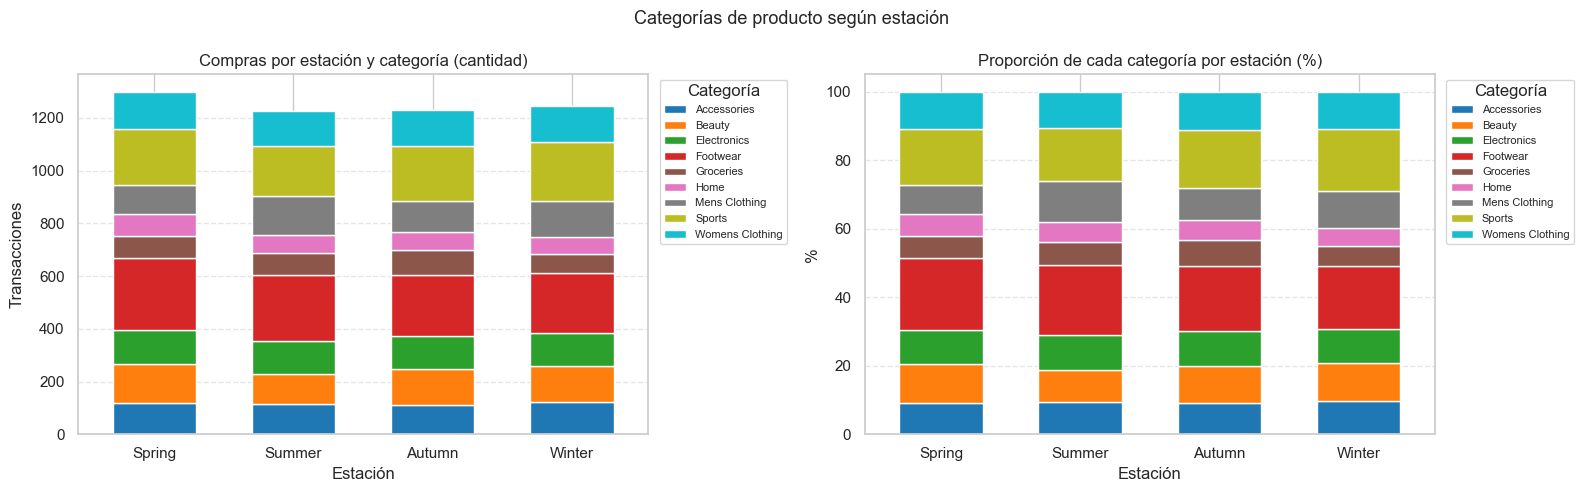

NameError: name 'deviation' is not defined

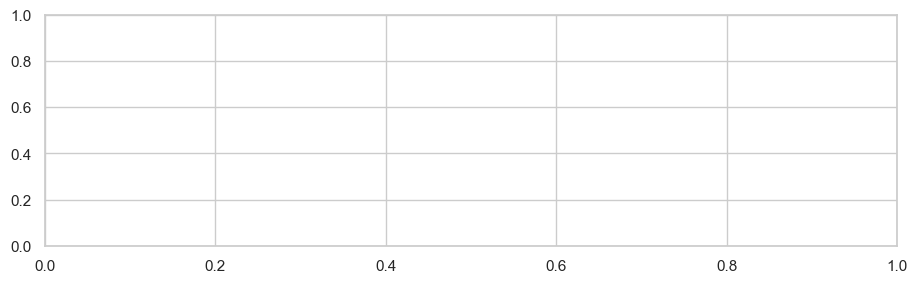

In [31]:
# ¿Qué categorías se compran más (y menos) en cada estación?

season_order = ["Spring", "Summer", "Autumn", "Winter"]

season_cat = (
    df.groupby(["Season", "Category"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(season_order)
)
season_cat_pct = season_cat.div(season_cat.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

season_cat.plot(kind="bar", stacked=True, ax=axes[0],
                colormap="tab10", edgecolor="white", width=0.6)
axes[0].set_title("Compras por estación y categoría (cantidad)")
axes[0].set_xlabel("Estación")
axes[0].set_ylabel("Transacciones")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Categoría", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[0].grid(axis="y", ls="--", alpha=0.5)

season_cat_pct.plot(kind="bar", stacked=True, ax=axes[1],
                    colormap="tab10", edgecolor="white", width=0.6)
axes[1].set_title("Proporción de cada categoría por estación (%)")
axes[1].set_xlabel("Estación")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Categoría", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].grid(axis="y", ls="--", alpha=0.5)

plt.suptitle("Categorías de producto según estación", fontsize=13)
plt.tight_layout()
plt.show()

# Heatmap: desvío de cada categoría respecto a su promedio estacional
fig, ax = plt.subplots(figsize=(11, 3))

sns.heatmap(
    deviation,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Desvío % resp a la media"}
)

ax.set_title(
    "¿Qué categorías se compran más o menos según la estación?\n"
    "(verde = más que el promedio, rojo = menos)"
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Estación")

ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

#### Observaciones — categorías por estación

El gráfico de barras apiladas y el heatmap de desvíos muestran que la estructura de categorías se mantiene bastante estable entre estaciones, sin cambios fuertes en la composición general del consumo.

- **Electronics** presenta una variación leve entre estaciones: aparece ligeramente por encima del promedio en otoño y por debajo en verano.

- **Footwear** muestra una mayor participación en primavera y verano, lo que sugiere un comportamiento parcialmente estacional del consumo en esta categoría.

- **Sports** tiende a ser relativamente más alto en invierno, mientras que en otras estaciones se mantiene cercano al promedio.

- **Groceries** y el resto de las categorías presentan variaciones pequeñas y bastante estables entre estaciones, sin patrones estacionales claros.

En conjunto, las diferencias observadas son leves y no indican una estacionalidad fuerte en la distribución de categorías, lo que es consistente con la estabilidad general del volumen de transacciones por estación.

#### Barras: monto promedio por categoría de producto

In [ ]:
mean_amt = df.groupby('Category', observed=True)['Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=mean_amt.values, y=mean_amt.index, hue=mean_amt.index, palette='coolwarm', legend=False)
plt.xlabel('Monto promedio')
plt.ylabel('Category')
plt.title('Monto promedio por categoría')
plt.tight_layout()
plt.show()

#### Observaciones — monto promedio por `Category`
- **Electronics** tiene un ticket medio de \$1766, casi 12 veces el promedio general sin considerar esa categoría. Es un outlier de categoría que domina cualquier análisis de facturación agregada.
- **Groceries** está en el otro extremo: ticket medio de \$42, unas 42 veces menor que Electronics.
- La escala de precios entre categorías es enorme: Footwear (\$144), Sports (\$138), y Clothing (~\$113-117) forman un clúster de "precio medio".


---
## 6. Correlación entre variables numéricas
---


In [ ]:
cols_corr = ['Age', 'Amount', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']
cm = df[cols_corr].corr(method='pearson')
cm

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Pearson (variables numéricas)')
plt.tight_layout()
plt.show()

#### Observaciones — correlación de Pearson
- **`DiscountApplied(%)` ↔ `PreviousPurchases`: r = 0.73** → la correlación más fuerte del dataset y muy llamativa: **los clientes con más compras previas reciben descuentos más altos**. Puede ser un programa de fidelización o una regla de negocio explícita en los datos.
- **`Amount` tiene correlación ≈ 0 con todo**. El monto gastado **no depende linealmente** de la edad, el historial ni el descuento.
- **`ItemRating` ↔ `DiscountApplied(%)`**: r = 0.16 y **`ItemRating` ↔ `PreviousPurchases`**: r = 0.12 → clientes más fieles tienden a dar ratings ligeramente más altos, aunque la relación es débil.
- **`Age` es independiente de todo** (correlaciones < 0.04): la edad no predice ni el monto, ni el descuento, ni la satisfacción.


#### Spearman para comparar

In [ ]:
cm_s = df[cols_corr].corr(method='spearman')
plt.figure(figsize=(7, 5))
sns.heatmap(cm_s, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Spearman (rangos)')
plt.tight_layout()
plt.show()

#### Observaciones — correlación de Spearman
- **`DiscountApplied(%)` ↔ `PreviousPurchases`: ρ = 0.69** (Pearson = 0.73): la relación es principalmente **lineal**, no solo monótona. Ambos coeficientes son altos y muy similares.
- **`Amount` ↔ todo**: prácticamente cero también en Spearman (máx. |ρ| = 0.014). Esto descarta relaciones monotónicas ocultas; el monto simplemente **no correlaciona con el resto de variables continuas**.
- El heatmap de Spearman vs Pearson es casi idéntico, lo cual es consistente con la naturaleza del dataset (probablemente sintético con reglas simples).


---
## 7. Scatter plots entre pares de variables numéricas
---

In [ ]:
sns.pairplot(df[cols_corr].sample(min(500, len(df)), random_state=42), corner=True, diag_kind='kde')
plt.suptitle('Submuestra para pairplot (hasta 500 filas)', y=1.02)
plt.show()

#### Observaciones
- En la diagonal de **`Amount`** se ve la distribución bimodal: un pico grande cerca de \$0-200 (mayoría de categorías) y un pico pequeño alrededor de \$1500-2000 (Electronics). Muy llamativo visualmente.
- La nube **`DiscountApplied(%)` vs `PreviousPurchases`** es la única que muestra una tendencia diagonal clara (correlación r=0.73): a más compras previas, mayor descuento. Todas las demás nubes parecen ruido sin estructura.
- **`Amount`** vs cualquier otra variable: nubes completamente dispersas, confirmando la independencia estadística del monto respecto al perfil del cliente.


---
## 8. Conclusiones

### Lo que más llama la atención del análisis

**El monto (`Amount`) tiene una distribución muy sesgada hacia la derecha**

La mayor parte de las compras está por debajo de $185 (el 75% del dataset), pero la media llega a $285 porque un conjunto pequeño de transacciones de Electronics —con montos de hasta $2998— desplaza el promedio hacia arriba. En este caso, la mediana ($122) es considerablemente más representativa del cliente típico que la media.

Vale destacar también que la banda de ±1 desvío estándar de `Amount` se extiende hasta valores negativos, lo que carece de sentido para un monto de compra. Esto ilustra con claridad que la desviación estándar no es una medida adecuada de dispersión cuando la distribución es tan asimétrica.

**La correlación entre descuento y compras previas (r = 0.73)**

Es la relación más fuerte del dataset. Los clientes con más compras previas reciben de forma consistente descuentos más altos, lo que sugiere algún tipo de beneficio por fidelización en los datos. Resulta relevante que tanto Pearson como Spearman arrojen valores similares (0.73 y 0.69 respectivamente), lo que indica que la relación es principalmente lineal.

**Electronics como categoría con mayor incidencia en los montos**

Electronics representa solo el 10% de las transacciones, pero su monto promedio ($1766) está muy por encima del resto de las categorías (que oscilan entre $42 y $162). Esto explica la mayor parte de los patrones observados a lo largo del análisis: la media elevada de `Amount`, la diferencia entre géneros (los hombres concentran las compras de Electronics), y la marcada asimetría de la distribución. Al analizar el comportamiento de compra en general, es importante tener en cuenta este peso desproporcionado de Electronics en los montos.

**La temporada y la edad no muestran incidencia en el monto**

Las medianas de `Amount` por estación son prácticamente iguales ($120-$124). La correlación de `Age` con el resto de las variables es cercana a cero en todos los casos. No se encontró ningún patrón relevante asociado a la edad del cliente ni a la época del año.

### Otros aspectos

- El balance exactamente 50/50 entre géneros y la distribución ~25% por estación son demasiado uniformes para corresponder a datos reales. Es conocido que el dataset fue construido o muestreado de manera controlada.
- El 80% de los pagos se realizan con tarjeta. No queda claro si esto refleja las características de algún mercado en particular o si es una simplificación del dataset.
- No es posible determinar, a partir de estos datos, si la relación entre descuento y antigüedad de compra responde a una política real de fidelización o simplemente a una regla con la que se generaron los datos.

### Síntesis general

El factor con mayor incidencia en los resultados es **Electronics**: eleva la media de `Amount`, genera la principal diferencia entre géneros y es responsable de la asimetría en la distribución de montos. El resto de las variables —edad, temporada, calificación del producto— no presentan relaciones fuertes entre sí ni con el monto gastado.
